<a href="https://colab.research.google.com/github/maulsabani01-cell/Tugas-data-mining-2304020137/blob/main/Hasil_Prediksi_137.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#UTS Data Mining
Maulana Nur Sa'bani

NIM 2304020137

Rombel 3

**Langkah-langkah pengerjaan:**
1. Install & Import Library
2. Upload dan Load Dataset
3. Eksplorasi Data
4. Pembersihan Data
5. Featuring Engineering dan Scaling
6. Pembuatan Model
7. Evaluasi Model Terbaik
8. Retrain Model
9. Prediksi Data Testing & Simpan Hasil

## 1. Install & Import Library

In [25]:
# Install library tambahan jika diperlukan
!pip install scikit-learn pandas numpy matplotlib seaborn joblib -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, ConfusionMatrixDisplay
)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import joblib

# Untuk tampilan lebih rapi
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='husl')


## 2. Upload & Load Dataset

Upload file `data_training.csv` dan `data_testing.csv`

In [2]:
# Upload file ke Google Colab
from google.colab import files

print('📂 Silakan upload file data_training.csv dan data_testing.csv')
uploaded = files.upload()

📂 Silakan upload file data_training.csv dan data_testing.csv


Saving data_training.csv to data_training.csv
Saving data_testing.csv to data_testing.csv


In [26]:
# Load dataset
df_train = pd.read_csv('data_training.csv')
df_test  = pd.read_csv('data_testing.csv')

## 3. Eksplorasi Data (EDA)

In [29]:
# Tampilkan training data
df_train.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3000,0.7400,0.0800,1.7000,0.0940,10.0000,45.0000,0.9958,3.2400,0.5000,9.8000,5,1366
1,8.1000,0.5750,0.2200,2.1000,0.0770,12.0000,65.0000,0.9967,3.2900,0.5100,9.2000,5,103
2,10.1000,0.4300,0.4000,2.6000,0.0920,13.0000,52.0000,0.9983,3.2200,0.6400,10.0000,7,942
3,12.9000,0.5000,0.5500,2.8000,0.0720,7.0000,24.0000,1.0001,3.0900,0.6800,10.9000,6,811
4,8.4000,0.3600,0.3200,2.2000,0.0810,32.0000,79.0000,0.9964,3.3000,0.7200,11.0000,6,918


In [30]:
# Informasi dasar dataset
df_train.info()
df_train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,857.0000,857.0000,857.0000,857.0000,857.0000,857.0000,857.0000,857.0000,857.0000,857.0000,857.0000,857.0000,857.0000
mean,8.2620,0.5294,0.2674,2.5062,0.0868,15.7830,45.9784,0.9967,3.3131,0.6567,10.4303,5.6534,813.7491
std,1.7020,0.1792,0.1951,1.2935,0.0487,10.3004,31.6921,0.0019,0.1521,0.1674,1.0670,0.8218,463.8071
min,4.6000,0.1200,0.0000,0.9000,0.0120,1.0000,6.0000,0.9901,2.7400,0.3900,8.4000,3.0000,0.0000
25%,7.1000,0.3950,0.0900,1.9000,0.0700,7.0000,21.0000,0.9955,3.2100,0.5500,9.5000,5.0000,413.0000
50%,7.9000,0.5200,0.2500,2.2000,0.0790,14.0000,38.0000,0.9967,3.3100,0.6200,10.2000,6.0000,814.0000
75%,9.1000,0.6400,0.4200,2.6000,0.0900,21.0000,63.0000,0.9978,3.4000,0.7300,11.1000,6.0000,1214.0000
max,15.6000,1.5800,1.0000,15.5000,0.6110,68.0000,278.0000,1.0032,4.0100,2.0000,14.0000,8.0000,1597.0000


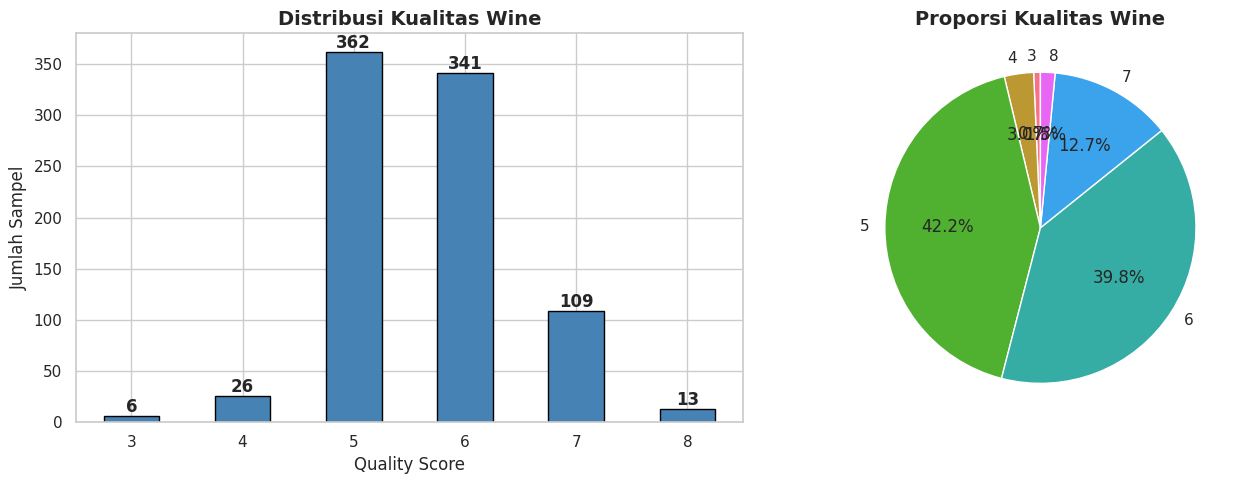

In [31]:
# Cek distribusi target (quality)
quality_counts = df_train['quality'].value_counts().sort_index()

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
quality_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Distribusi Kualitas Wine', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Quality Score')
axes[0].set_ylabel('Jumlah Sampel')
axes[0].tick_params(axis='x', rotation=0)
for bar in axes[0].patches:
    axes[0].annotate(f'{int(bar.get_height())}',
                     (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     ha='center', va='bottom', fontweight='bold')

# Pie chart
quality_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporsi Kualitas Wine', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('distribusi_quality.png', dpi=150, bbox_inches='tight')
plt.show()

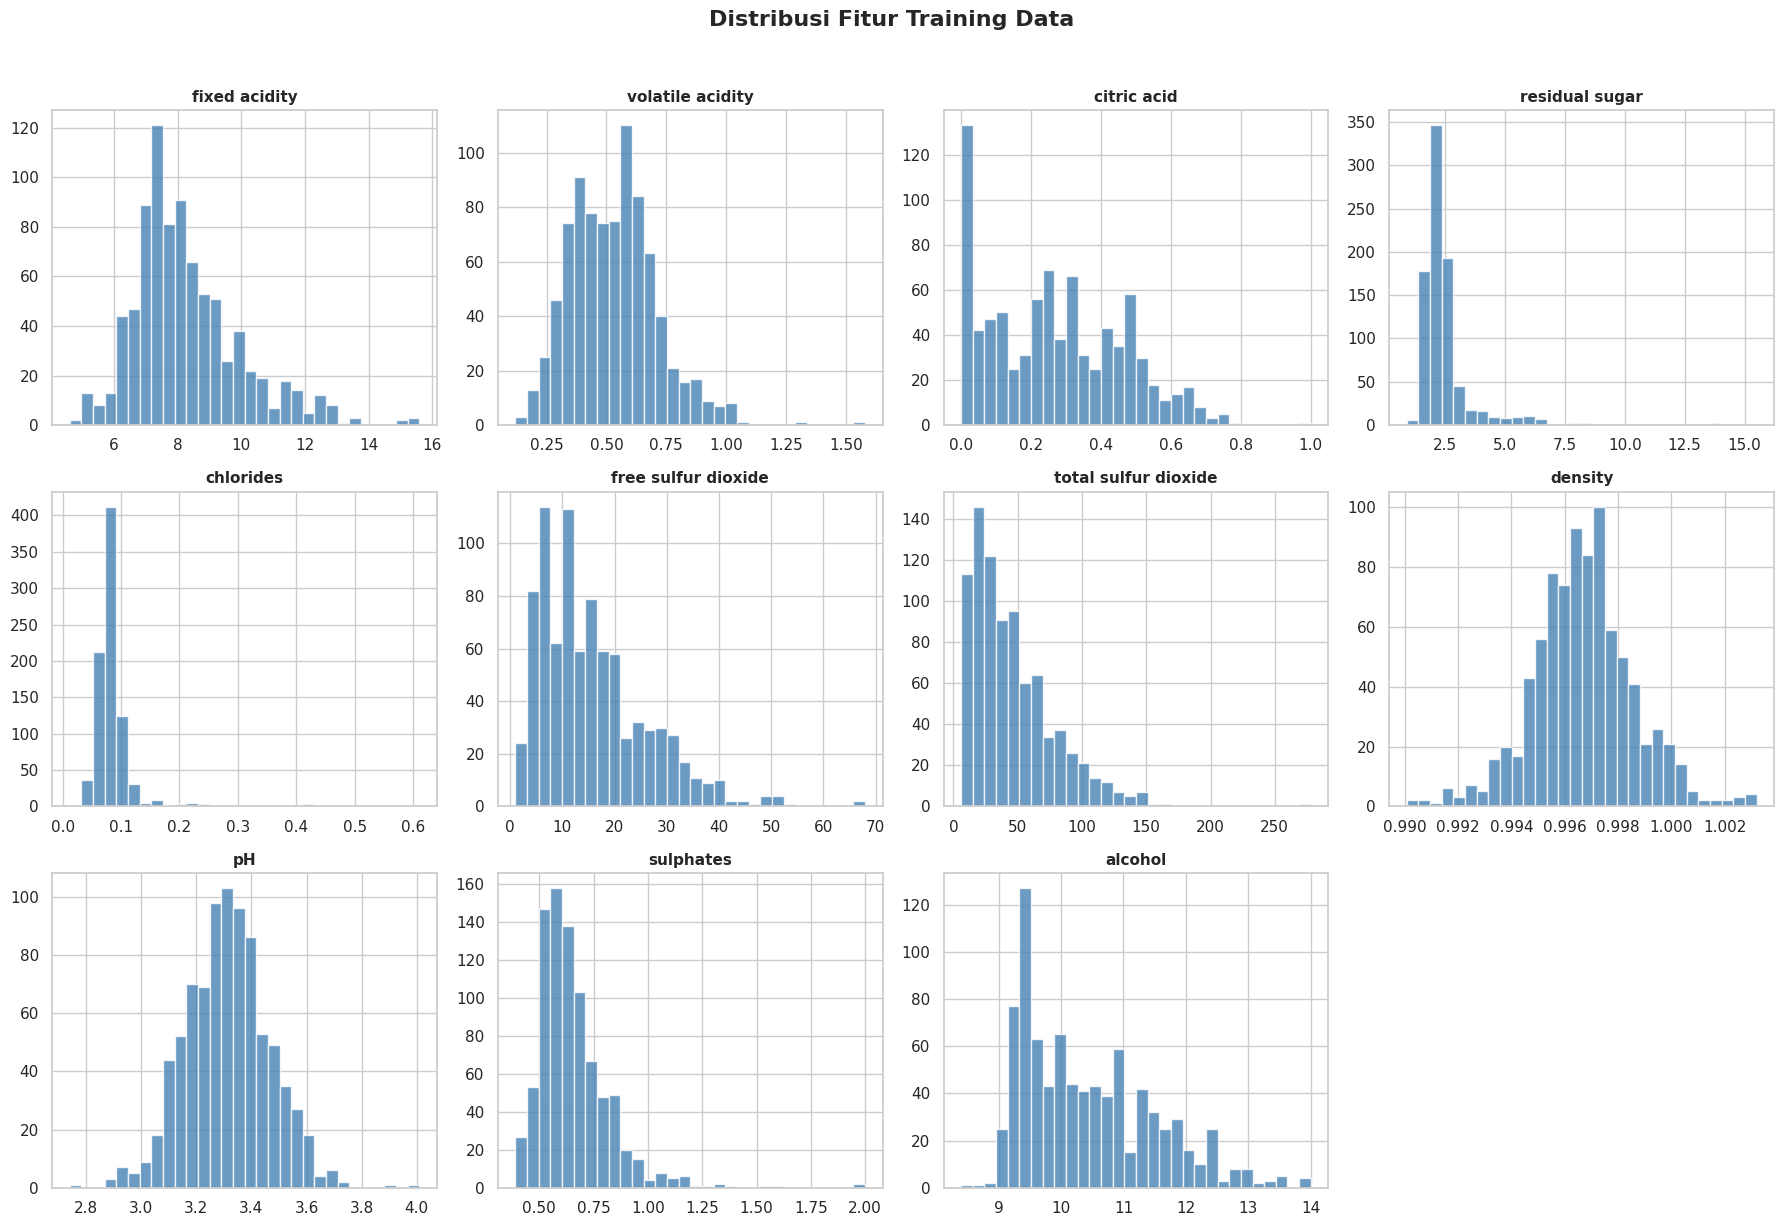

In [7]:
# Visualisasi distribusi setiap fitur
features = [c for c in df_train.columns if c not in ['quality', 'Id']]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, feat in enumerate(features):
    df_train[feat].hist(ax=axes[i], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(feat, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')

# Sembunyikan axes kosong jika ada
for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur Training Data', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('distribusi_fitur.png', dpi=150, bbox_inches='tight')
plt.show()

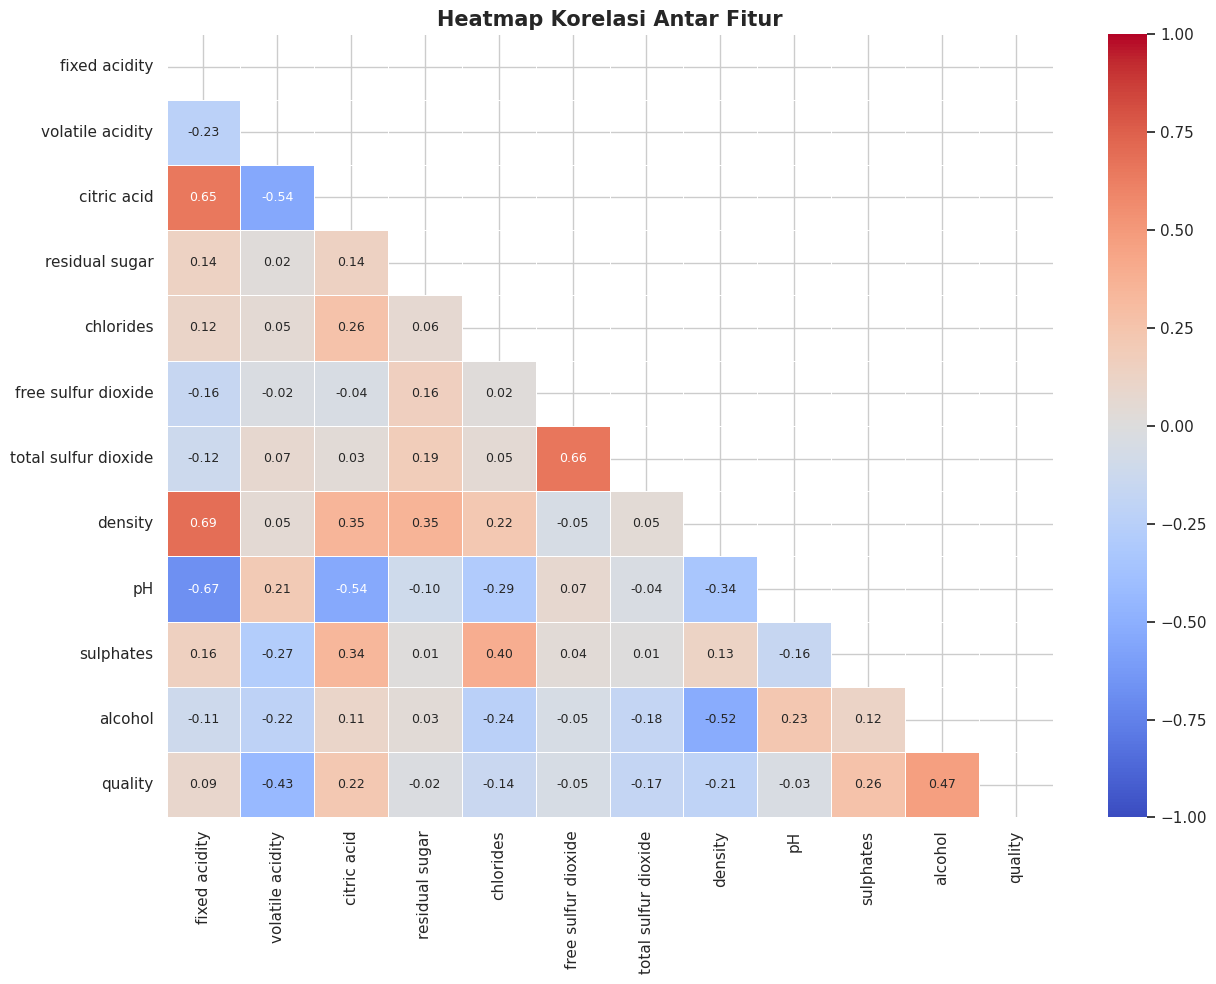

KORELASI FITUR TERHADAP QUALITY (diurutkan)
alcohol                0.4736
volatile acidity       0.4301
sulphates              0.2607
citric acid            0.2213
density                0.2079
total sulfur dioxide   0.1727
chlorides              0.1449
fixed acidity          0.0927
free sulfur dioxide    0.0545
pH                     0.0332
residual sugar         0.0205
Name: quality, dtype: float64


In [33]:
# Heatmap korelasi
plt.figure(figsize=(13, 10))
corr_matrix = df_train[features + ['quality']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 9})
plt.title('Heatmap Korelasi Antar Fitur', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()

# Fitur dengan korelasi tertinggi ke quality
corr_quality = corr_matrix['quality'].drop('quality').abs().sort_values(ascending=False)
print('KORELASI FITUR TERHADAP QUALITY (diurutkan)')
print(corr_quality)

## 4. Pembersihan Data

In [34]:
# Cek missing values
print('MISSING VALUES - TRAINING')
mv_train = df_train.isnull().sum()
print(mv_train[mv_train > 0] if mv_train.sum() > 0 else 'Tidak ada missing values')

print('MISSING VALUES - TESTING')
mv_test = df_test.isnull().sum()
print(mv_test[mv_test > 0] if mv_test.sum() > 0 else 'Tidak ada missing values')

MISSING VALUES - TRAINING
Tidak ada missing values
MISSING VALUES - TESTING
Tidak ada missing values


In [36]:
# Penanganan missing values (jika ada, lakukan median imputation)
imputer = SimpleImputer(strategy='median')

# Cek dan tangani data duplikat
dup_count = df_train.duplicated().sum()
print(f'Jumlah duplikat di training: {dup_count}')
if dup_count > 0:
    df_train = df_train.drop_duplicates()
    print(f'Duplikat dihapus. Ukuran baru: {df_train.shape}')
else:
    print('Tidak ada duplikat')

# Cek outlier menggunakan IQR
print('DETEKSI OUTLIER (IQR Method)')
for feat in features:
    Q1 = df_train[feat].quantile(0.25)
    Q3 = df_train[feat].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df_train[feat] < Q1 - 1.5*IQR) | (df_train[feat] > Q3 + 1.5*IQR)).sum()
    if outliers > 0:
        print(f'  {feat}: {outliers} outlier')

Jumlah duplikat di training: 0
Tidak ada duplikat
DETEKSI OUTLIER (IQR Method)
  fixed acidity: 30 outlier
  volatile acidity: 8 outlier
  citric acid: 1 outlier
  residual sugar: 76 outlier
  chlorides: 59 outlier
  free sulfur dioxide: 15 outlier
  total sulfur dioxide: 19 outlier
  density: 25 outlier
  pH: 14 outlier
  sulphates: 31 outlier
  alcohol: 9 outlier


## 5. Feature Engineering & Scaling

In [37]:
# Simpan Id testing untuk output akhir
test_ids = df_test['Id'].copy()

# Pisahkan fitur dan target
X = df_train[features].copy()
y = df_train['quality'].copy()
X_test_final = df_test[features].copy()

# Tambah feature engineering: rasio dan interaksi antar fitur
def add_features(df):
    df = df.copy()
    df['free_to_total_SO2']    = df['free sulfur dioxide'] / (df['total sulfur dioxide'] + 1e-6)
    df['acidity_ratio']        = df['fixed acidity'] / (df['volatile acidity'] + 1e-6)
    df['alcohol_density_ratio']= df['alcohol'] / (df['density'] + 1e-6)
    df['total_acidity']        = df['fixed acidity'] + df['volatile acidity'] + df['citric acid']
    return df

X            = add_features(X)
X_test_final = add_features(X_test_final)

print(f'Jumlah fitur setelah feature engineering: {X.shape[1]}')
print('Fitur baru:', ['free_to_total_SO2', 'acidity_ratio', 'alcohol_density_ratio', 'total_acidity'])

Jumlah fitur setelah feature engineering: 15
Fitur baru: ['free_to_total_SO2', 'acidity_ratio', 'alcohol_density_ratio', 'total_acidity']


In [38]:
# Split data training -> train & validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Gunakan RobustScaler (tahan terhadap outlier)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test_final)

print(f'X_train: {X_train_scaled.shape}, X_val: {X_val_scaled.shape}')
print('Scaling selesai menggunakan RobustScaler')

X_train: (685, 15), X_val: (172, 15)
Scaling selesai menggunakan RobustScaler


## 6. Pembuatan Model

In [42]:
#MODEL 1: Random Forest
print('Training Random Forest')
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)
rf_val_pred = rf_model.predict(X_val_scaled)
rf_acc = accuracy_score(y_val, rf_val_pred)
rf_f1  = f1_score(y_val, rf_val_pred, average='weighted')
print(f'Akurasi Validasi : {rf_acc:.4f} ({rf_acc*100:.2f}%)')
print(f'F1-Score (weighted): {rf_f1:.4f}')

Training Random Forest
Akurasi Validasi : 0.6105 (61.05%)
F1-Score (weighted): 0.5881


In [43]:
#MODEL 2: Gradient Boosting
print('Training Gradient Boosting')
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    min_samples_split=5,
    min_samples_leaf=3,
    subsample=0.8,
    random_state=42
)
gb_model.fit(X_train_scaled, y_train)
gb_val_pred = gb_model.predict(X_val_scaled)
gb_acc = accuracy_score(y_val, gb_val_pred)
gb_f1  = f1_score(y_val, gb_val_pred, average='weighted')
print(f'Akurasi Validasi : {gb_acc:.4f} ({gb_acc*100:.2f}%)')
print(f' F1-Score (weighted): {gb_f1:.4f}')

Training Gradient Boosting
Akurasi Validasi : 0.5640 (56.40%)
 F1-Score (weighted): 0.5457


In [44]:
#MODEL 3: XGBoost (jika tersedia)
try:
    from xgboost import XGBClassifier
    print('Training XGBoost')

    # XGBoost butuh label mulai dari 0
    label_offset = y.min()
    y_train_xgb = y_train - label_offset
    y_val_xgb   = y_val   - label_offset

    xgb_model = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    )
    xgb_model.fit(
        X_train_scaled, y_train_xgb,
        eval_set=[(X_val_scaled, y_val_xgb)],
        verbose=False
    )
    xgb_val_pred = xgb_model.predict(X_val_scaled) + label_offset
    xgb_acc = accuracy_score(y_val, xgb_val_pred)
    xgb_f1  = f1_score(y_val, xgb_val_pred, average='weighted')
    print(f'Akurasi Validasi : {xgb_acc:.4f} ({xgb_acc*100:.2f}%)')
    print(f'F1-Score (weighted): {xgb_f1:.4f}')
    USE_XGB = True
except ImportError:
    print('XGBoost tidak tersedia, install dengan: !pip install xgboost')
    USE_XGB = False

Training XGBoost
Akurasi Validasi : 0.5698 (56.98%)
F1-Score (weighted): 0.5581


PERBANDINGAN MODEL
                   Accuracy  F1-Score
Random Forest        0.6105    0.5881
Gradient Boosting    0.5640    0.5457
XGBoost              0.5698    0.5581


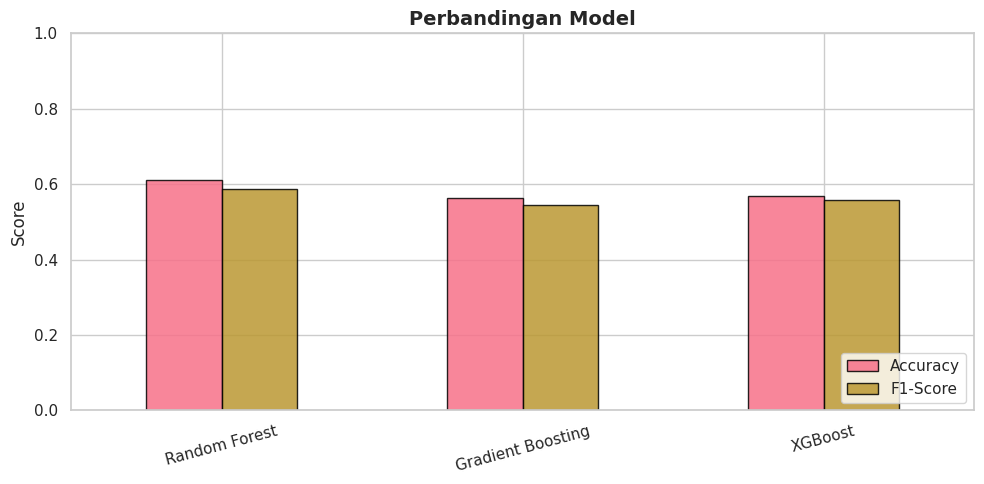

Model terbaik: Random Forest (Akurasi: 0.6105)


In [45]:
# Perbandingan semua model
results = {
    'Random Forest'    : {'Accuracy': rf_acc, 'F1-Score': rf_f1},
    'Gradient Boosting': {'Accuracy': gb_acc, 'F1-Score': gb_f1},
}
if USE_XGB:
    results['XGBoost'] = {'Accuracy': xgb_acc, 'F1-Score': xgb_f1}

df_results = pd.DataFrame(results).T
print('PERBANDINGAN MODEL')
print(df_results.to_string())

# Visualisasi
df_results.plot(kind='bar', figsize=(10, 5), ylim=(0, 1), edgecolor='black', alpha=0.85)
plt.title('Perbandingan Model', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Pilih model terbaik
best_model_name = df_results['Accuracy'].idxmax()
print(f'Model terbaik: {best_model_name} (Akurasi: {df_results.loc[best_model_name, "Accuracy"]:.4f})')

## 7. Evaluasi Model Terbaik

In [46]:
# Pilih model terbaik berdasarkan akurasi
model_map = {
    'Random Forest'    : (rf_model, rf_val_pred),
    'Gradient Boosting': (gb_model, gb_val_pred),
}
if USE_XGB:
    model_map['XGBoost'] = (xgb_model, xgb_val_pred)

best_model, best_val_pred = model_map[best_model_name]

print(f'LAPORAN KLASIFIKASI: {best_model_name}')
print(classification_report(y_val, best_val_pred))

LAPORAN KLASIFIKASI: Random Forest
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.65      0.79      0.72        73
           6       0.56      0.59      0.58        68
           7       0.60      0.27      0.38        22
           8       1.00      0.33      0.50         3

    accuracy                           0.61       172
   macro avg       0.47      0.33      0.36       172
weighted avg       0.59      0.61      0.59       172



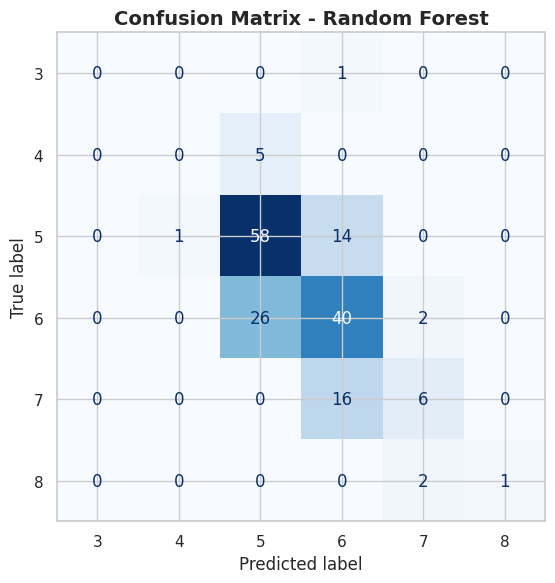

CROSS-VALIDATION (5-Fold Stratified)
Skor tiap fold: [0.5756 0.6686 0.6023 0.6608 0.6901]
Rata-rata     : 0.6395 ± 0.0432


In [47]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_val, best_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(y.unique()))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Cross-validation
print('CROSS-VALIDATION (5-Fold Stratified)')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, scaler.transform(add_features(X)), y,
                             cv=cv, scoring='accuracy', n_jobs=-1)
print(f'Skor tiap fold: {cv_scores.round(4)}')
print(f'Rata-rata     : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

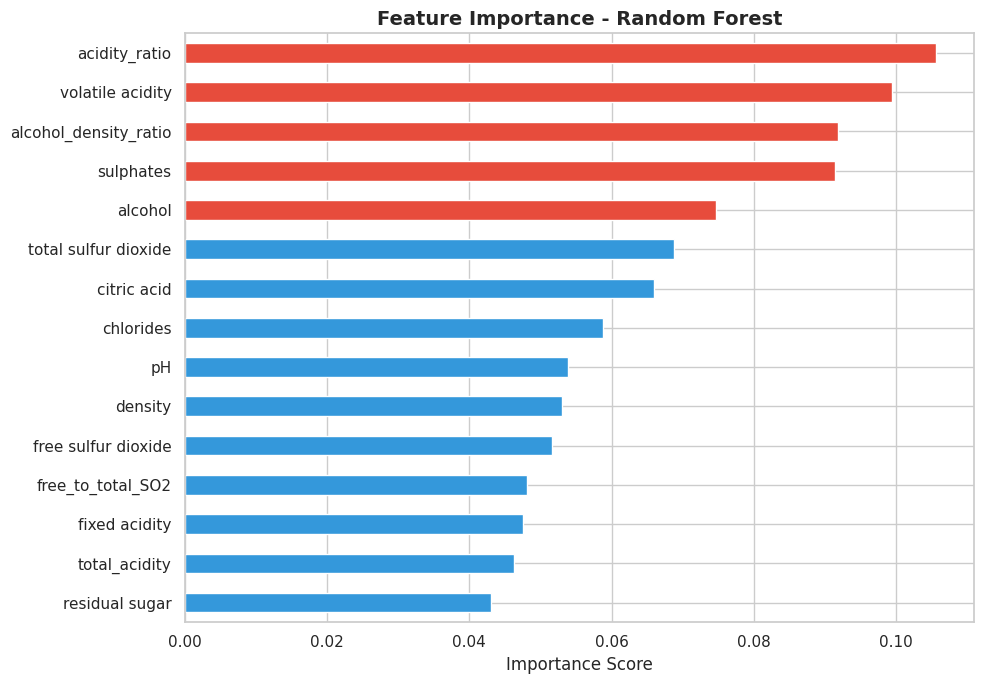

TOP 5 FITUR PALING PENTING
acidity_ratio           0.1057
volatile acidity        0.0994
alcohol_density_ratio   0.0918
sulphates               0.0914
alcohol                 0.0747


In [49]:
# Feature Importance
if hasattr(best_model, 'feature_importances_'):
    feat_names = X.columns.tolist()
    importances = pd.Series(best_model.feature_importances_, index=feat_names)
    importances = importances.sort_values(ascending=True)

    plt.figure(figsize=(10, 7))
    colors = ['#e74c3c' if i >= len(importances)-5 else '#3498db' for i in range(len(importances))]
    importances.plot(kind='barh', color=colors, edgecolor='white')
    plt.title(f'Feature Importance - {best_model_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('TOP 5 FITUR PALING PENTING')
    print(importances.tail(5).sort_values(ascending=False).to_string())

## 8. Retrain Model pada Seluruh Data Training

In [50]:
# Retrain dengan SELURUH data training (X + y penuh)
print(f'Melatih ulang {best_model_name} dengan seluruh data training')

X_full        = add_features(df_train[features])
y_full        = df_train['quality']

scaler_full   = RobustScaler()
X_full_scaled = scaler_full.fit_transform(X_full)
X_test_scaled_final = scaler_full.transform(add_features(df_test[features]))

# Gunakan parameter terbaik dari model terpilih
if best_model_name == 'Random Forest':
    final_model = RandomForestClassifier(**rf_model.get_params())
elif best_model_name == 'Gradient Boosting':
    final_model = GradientBoostingClassifier(**gb_model.get_params())
elif best_model_name == 'XGBoost':
    final_model = XGBClassifier(**xgb_model.get_params())
    y_full = y_full - label_offset  # shift label untuk XGBoost

final_model.fit(X_full_scaled, y_full)
print(f'Model final berhasil dilatih pada {len(y_full)} sampel')

Melatih ulang Random Forest dengan seluruh data training
Model final berhasil dilatih pada 857 sampel


## 9. Prediksi Data Testing & Simpan Hasil

In [52]:
# Prediksi data testing
y_test_pred = final_model.predict(X_test_scaled_final)

# Kembalikan label ke aslinya jika XGBoost
if best_model_name == 'XGBoost' and USE_XGB:
    y_test_pred = y_test_pred + label_offset

# Buat DataFrame hasil prediksi
submission = pd.DataFrame({
    'Id'     : test_ids,
    'quality': y_test_pred
})
submission

,Id,quality
0,222,5
1,1514,6
2,417,5
3,754,5
4,516,5
...,...,...
281,1147,6
282,296,5
283,170,5
284,1439,6


## Ringkasan

| Langkah | Keterangan |
|---------|------------|
| Dataset | 857 training, 286 testing |
| Fitur | 11 fitur asli + 4 fitur baru = 15 fitur |
| Missing Values | Tidak ada |
| Scaling | RobustScaler (tahan outlier) |
| Model | Random Forest, Gradient Boosting, XGBoost |
| Evaluasi | Akurasi, F1-Score, Confusion Matrix, Cross-Val 5-Fold |